Training data shape: (50000, 3072)
Test data shape: (10000, 3072)
Number of superclasses: 20
Superclasses: ['aquatic_mammals', 'fish', 'flowers', 'food_containers', 'fruit_and_vegetables', 'household_electrical_devices', 'household_furniture', 'insects', 'large_carnivores', 'large_man-made_outdoor_things', 'large_natural_outdoor_scenes', 'large_omnivores_and_herbivores', 'medium_mammals', 'non-insect_invertebrates', 'people', 'reptiles', 'small_mammals', 'trees', 'vehicles_1', 'vehicles_2']


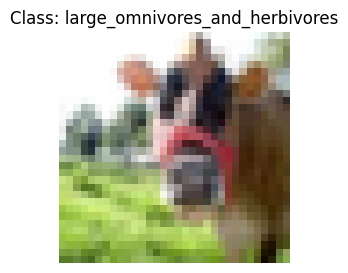

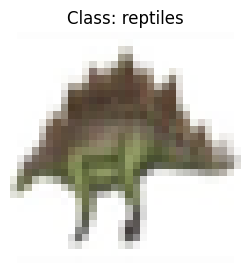

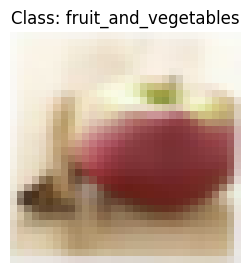

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Labels: tensor([15, 12,  7, 12,  1, 16, 15,  8, 13,  8, 16,  1,  0, 12, 10,  6,  0,  6,
         5,  9, 10, 19, 13, 15,  4,  0,  5, 17, 18,  3,  9, 12])


In [2]:
import torch
import numpy as np
import pandas as pd
from PIL import Image
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pickle
import matplotlib.pyplot as plt

def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Load CIFAR-100 data
metadata_path = '/kaggle/input/cifar100/meta'
metadata = unpickle(metadata_path)
superclass_dict = dict(list(enumerate(metadata[b'coarse_label_names'])))

data_pre_path = '/kaggle/input/cifar100/'
data_train_path = data_pre_path + 'train'
data_test_path = data_pre_path + 'test'

data_train_dict = unpickle(data_train_path)
data_test_dict = unpickle(data_test_path)

data_train = data_train_dict[b'data']
label_train = np.array(data_train_dict[b'coarse_labels'])
data_test = data_test_dict[b'data']
label_test = np.array(data_test_dict[b'coarse_labels'])

# Print dataset info
print(f"Training data shape: {data_train.shape}")
print(f"Test data shape: {data_test.shape}")
print(f"Number of superclasses: {len(superclass_dict)}")
print(f"Superclasses: {[superclass_dict[i].decode('utf-8') for i in range(len(superclass_dict))]}")

# Create a custom dataset for CIFAR-100
class CIFAR100Dataset(Dataset):
    def __init__(self, data, labels, transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # CIFAR-100 images are stored as flat arrays in the format R, G, B
        # We need to reshape them to 32x32x3
        image = self.data[idx].reshape(3, 32, 32).transpose(1, 2, 0)
        label = self.labels[idx]
        
        if self.transform:
            transformed = self.transform(image=image)
            image = transformed["image"]
            
        return image, label
    
    def visualize_sample(self, idx):
        """Visualize a sample image with its label"""
        image = self.data[idx].reshape(3, 32, 32).transpose(1, 2, 0)
        label = self.labels[idx]
        plt.figure(figsize=(3, 3))
        plt.imshow(image)
        plt.title(f"Class: {superclass_dict[label].decode('utf-8')}")
        plt.axis('off')
        plt.show()
        

# Define transforms
train_transform = A.Compose([
    A.Resize(224, 224),
    A.Rotate(limit=40, p=0.9, border_mode=cv2.BORDER_CONSTANT),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.RGBShift(r_shift_limit=25, g_shift_limit=25, b_shift_limit=25, p=0.9),
    A.OneOf([
        A.Blur(blur_limit=3, p=0.5),
        A.ColorJitter(p=0.5),
    ], p=1.0),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

# Create datasets
train_dataset = CIFAR100Dataset(data_train, label_train, transform=train_transform)
test_dataset = CIFAR100Dataset(data_test, label_test, transform=val_transform)

# Optional: Visualize some samples before transformation
for i in range(3):
    train_dataset.visualize_sample(i)

# Create train/validation split from the training data
train_indices, val_indices = train_test_split(
    range(len(train_dataset)),
    test_size=0.2,
    stratify=label_train,
    random_state=42
)

# Create subset datasets
from torch.utils.data import Subset
train_dataset_final = Subset(train_dataset, train_indices)
val_dataset = Subset(train_dataset, val_indices)

# Create dataloaders
train_loader = DataLoader(
    train_dataset_final,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

# Check a batch
for images, labels in train_loader:
    print(f"Image batch shape: {images.shape}")  # Should be [batch_size, 3, 224, 224]
    print(f"Label batch shape: {labels.shape}")
    print(f"Labels: {labels}")
    break

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from transformers import ViTConfig, ViTForImageClassification
import numpy as np
from tqdm.auto import tqdm

# 1. Define ViT-B configuration
config = ViTConfig(
    hidden_size=768,
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=3072,
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    num_channels=3,
    image_size=224,
    patch_size=16,
    num_labels=20,  # For CIFAR-100 superclasses
)

# 2. Initialize a model from scratch (not pretrained)
model = ViTForImageClassification(config)
print(f"Model parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

# 3. Define training hyperparameters
num_epochs = 100
lr = 3e-4
weight_decay = 0.05
batch_size = 64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 4. Move model to device
model.to(device)

# 5. Define optimizer (AdamW commonly used for transformers)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=weight_decay,
    betas=(0.9, 0.999)
)

# 6. Learning rate scheduler (cosine with warmup)
from transformers import get_cosine_schedule_with_warmup
num_training_steps = len(train_loader) * num_epochs
num_warmup_steps = int(0.1 * num_training_steps)  # 10% warmup
scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

# 7. Define training function with MixUp/CutMix
def train_epoch(model, train_loader, optimizer, scheduler, device, epoch):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    
    for batch_idx, (inputs, targets) in enumerate(progress_bar):
        inputs, targets = inputs.to(device), targets.to(device)
        
        
        # Forward pass
        outputs = model(inputs).logits
        loss = nn.CrossEntropyLoss()(outputs, targets)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping (optional but helps with stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        scheduler.step()
        
        # Update metrics
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        
        correct += predicted.eq(targets).sum().item()
    
        # Update progress bar
        progress_bar.set_postfix({
            'Loss': train_loss / (batch_idx + 1),
            'Acc': 100. * correct / total,
            'LR': scheduler.get_last_lr()[0]
        })
    
    return train_loss / len(train_loader), 100. * correct / total



# 8. Define validation function
def validate(model, val_loader, device):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        progress_bar = tqdm(val_loader)
        for batch_idx, (inputs, targets) in enumerate(progress_bar):
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(inputs).logits
            loss = nn.CrossEntropyLoss()(outputs, targets)
            
            # Update metrics
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # Update progress bar
            progress_bar.set_postfix({
                'Loss': val_loss / (batch_idx + 1),
                'Acc': 100. * correct / total
            })
    
    return val_loss / len(val_loader), 100. * correct / total

# 9. Training loop
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device, epoch)
    val_loss, val_acc = validate(model, val_loader, device)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        print(f"Saving best model with validation accuracy: {val_acc:.2f}%")
        torch.save(model.state_dict(), "vit_best_model.pth")

# 10. Load best model and evaluate on test set
model.load_state_dict(torch.load("vit_best_model.pth"))
test_loss, test_acc = validate(model, test_loader, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

# 11. Save model in Hugging Face format
model.save_pretrained("vit-base-cifar100")

In [4]:
for img in test_loader:
    print(img)
    break

[tensor([[[[ 1.2899,  1.2899,  1.2899,  ...,  1.7180,  1.7180,  1.7180],
          [ 1.2899,  1.2899,  1.2899,  ...,  1.7180,  1.7180,  1.7180],
          [ 1.2899,  1.2899,  1.2899,  ...,  1.7180,  1.7180,  1.7180],
          ...,
          [-0.7479, -0.7479, -0.7479,  ...,  0.8961,  0.8961,  0.8961],
          [-0.7479, -0.7479, -0.7479,  ...,  0.8961,  0.8961,  0.8961],
          [-0.7479, -0.7479, -0.7479,  ...,  0.8961,  0.8961,  0.8961]],

         [[ 1.7283,  1.7283,  1.7283,  ...,  2.0609,  2.0609,  2.0609],
          [ 1.7283,  1.7283,  1.7283,  ...,  2.0609,  2.0609,  2.0609],
          [ 1.7283,  1.7283,  1.7283,  ...,  2.0609,  2.0609,  2.0609],
          ...,
          [-0.5476, -0.5476, -0.5476,  ...,  0.8354,  0.8354,  0.8354],
          [-0.5476, -0.5476, -0.5476,  ...,  0.8354,  0.8354,  0.8354],
          [-0.5476, -0.5476, -0.5476,  ...,  0.8354,  0.8354,  0.8354]],

         [[ 2.5354,  2.5354,  2.5354,  ...,  2.5877,  2.5877,  2.5877],
          [ 2.5354,  2.5354, 

In [40]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from transformers import ViTImageProcessor, ViTForImageClassification

# # 1. Load pretrained model and processor
# model_name = "google/vit-base-patch16-224"  # You can replace with your fine-tuned model path
# processor = ViTImageProcessor.from_pretrained(model_name)
# model = ViTForImageClassification.from_pretrained(model_name)

# # 2. Move model to device (GPU if available)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = model.to(device)
# model.eval()  # Set to evaluation mode

# 3. Define class names for CIFAR-100 superclasses (if using your fine-tuned model)
class_names = [
    "aquatic mammals", "fish", "flowers", "food containers", 
    "fruit and vegetables", "household electrical devices", "household furniture", 
    "insects", "large carnivores", "large man-made outdoor things", 
    "large natural outdoor scenes", "large omnivores and herbivores", 
    "medium-sized mammals", "non-insect invertebrates", "people", 
    "reptiles", "small mammals", "trees", "vehicles 1", "vehicles 2"
]

# 4. Function to predict a single image
def predict_image(image_path):
    # Load and preprocess the image
    # Define the mean and standard deviation used for normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).numpy()
    std = torch.tensor([0.229, 0.224, 0.225]).numpy()
    
    # Unnormalize the tensor
    unnormalized_tensor = image_path.permute(1,2,0).numpy() * std + mean
    plt.figure(figsize=(5, 5))
    plt.imshow(unnormalized_tensor)
    plt.axis('off')    # Display the image
   
    # Preprocess image for the model
    inputs = processor(images=unnormalized_tensor, return_tensors="pt").to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
    
    # Get predictions
    probs = torch.nn.functional.softmax(logits, dim=-1)
    probs = probs[0].cpu().numpy()
    
    # Get top 5 predictions
    top5_indices = np.argsort(probs)[-5:][::-1]
    top5_probs = probs[top5_indices]
    
    # Get class names for top predictions
    if hasattr(model.config, "id2label"):
        # Use model's built-in labels if available
        top5_labels = [model.config.id2label[idx] for idx in top5_indices]
    else:
        # Use our custom class names
        top5_labels = [class_names[idx] for idx in top5_indices]
    
    # Display results
    plt.title(f"Prediction: {top5_labels[0]}")
    plt.show()
    
    # Print detailed results
    print("Top 5 predictions:")
    for label, prob in zip(top5_labels, top5_probs):
        print(f"{label}: {prob:.4f}")
    
    return top5_labels, top5_probs

# 5. Function to predict a batch of images
def predict_batch(image_paths, batch_size=16):
    results = []
    
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = [Image.open(path).convert("RGB") for path in batch_paths]
        
        # Preprocess batch
        inputs = processor(images=batch_images, return_tensors="pt").to(device)
        
        # Forward pass
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
        
        # Get predictions
        probs = torch.nn.functional.softmax(logits, dim=-1)
        
        # Store results
        for j, path in enumerate(batch_paths):
            image_probs = probs[j].cpu().numpy()
            pred_idx = np.argmax(image_probs)
            
            if hasattr(model.config, "id2label"):
                pred_label = model.config.id2label[pred_idx]
            else:
                pred_label = class_names[pred_idx]
                
            results.append({
                "path": path,
                "prediction": pred_label,
                "confidence": float(image_probs[pred_idx])
            })
    
    return results

# 6. Example usage
# 
    # Single image prediction

    
    # Batch prediction example
    # image_paths = ["path/to/image1.jpg", "path/to/image2.jpg", "path/to/image3.jpg"]
    # results = predict_batch(image_paths)
    
    # for result in results:
    #     print(f"Image: {result['path']}")
    #     print(f"Prediction: {result['prediction']}")
    #     print(f"Confidence: {result['confidence']:.4f}")
    #     print("---")

torch.Size([3, 224, 224])


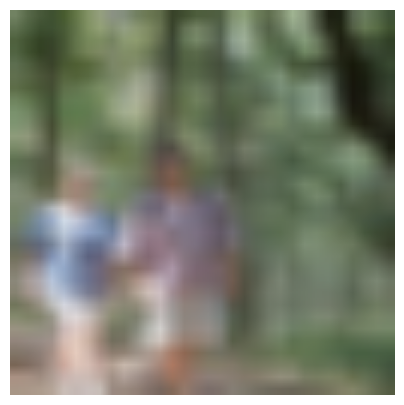

In [23]:
for img in test_loader:
    print(img[0][0].shape)
    
    # Define the mean and standard deviation used for normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).numpy()
    std = torch.tensor([0.229, 0.224, 0.225]).numpy()
    
    # Unnormalize the tensor
    unnormalized_tensor = img[0][1].permute(1,2,0).numpy() * std + mean
    plt.figure(figsize=(5, 5))
    plt.imshow(unnormalized_tensor)
    plt.axis('off')
    break

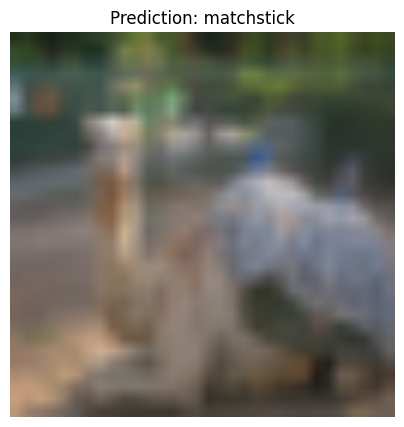

Top 5 predictions:
matchstick: 0.0316
nematode, nematode worm, roundworm: 0.0277
oboe, hautboy, hautbois: 0.0133
bassoon: 0.0133
revolver, six-gun, six-shooter: 0.0115


In [44]:
for img in test_loader:

    # print(img[0][0])
    predict_image(img[0][6])
    break

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import ViTForImageClassification, ViTFeatureExtractor
from tqdm import tqdm
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transforms for CIFAR-100
# The ViT model expects 224x224 images, so we need to resize
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load CIFAR-100 dataset
train_dataset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Load ViT model and feature extractor
model_name = "google/vit-base-patch16-224"
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=100,  # CIFAR-100 has 100 classes
    ignore_mismatched_sizes=True  # Important for changing the classifier head
)

# Move model to device
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=5e-5)

# Training function
def train(model, dataloader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device), targets.to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs).logits
        loss = criterion(outputs, targets)
        
        # Backward and optimize
        loss.backward()
        optimizer.step()
        
        # Calculate statistics
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': running_loss / (progress_bar.n + 1),
            'acc': 100. * correct / total
        })
    
    return running_loss / len(dataloader), 100. * correct / total

# Evaluation function
def evaluate(model, dataloader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Evaluating"):
            inputs, targets = inputs.to(device), targets.to(device)
            
            # Forward pass
            outputs = model(inputs).logits
            loss = criterion(outputs, targets)
            
            # Calculate statistics
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return running_loss / len(dataloader), 100. * correct / total

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, epoch)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    
    # Evaluate on test set
    test_loss, test_acc = evaluate(model, test_loader, criterion)
    print(f"Epoch {epoch+1}/{num_epochs} - Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

# Save the model
# torch.save(model.state_dict(), 'vit_cifar100.pth')
# print("Training completed and model saved!")